(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

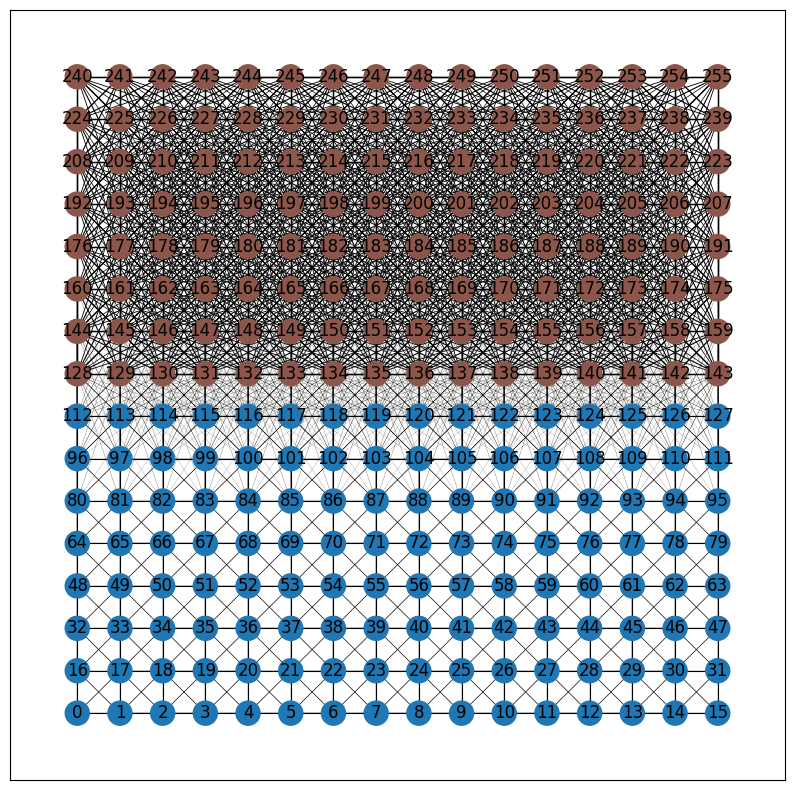

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from kuramoto.config import (
    SimulationConfig,
    GridConfig,
    CouplingConfig,
    InitThetaConfig,
    InitOmegaConfig,
    KernelComponentConfig,
    build_simulation,
)
from kuramoto.analysis import order_parameter, compute_effective_coupling, avg_effective_coupling
from kuramoto.adjoint import (
    grads_final_R, 
    grads_mean_R, 
    node_importance_from_gradK, 
    grads_final_R_alpha,
    grads_mean_R_alpha,
)
from kuramoto.plotting import plot_2d, plot_coupling_matrix
from kuramoto.network import (
    create_cortical_graph,
    plot_cortical_graph,
    get_degree,
    get_deg_centrality,
    get_closeness_centrality,
    get_betweenness_centrality,
    get_eigenvector_centrality,
)

from jax import numpy as jnp

SEED = 42
grid_shape = (16, 16)
T_END = 10.0
dt = 0.01

RNG = np.random.default_rng(SEED)


n_rows, n_cols = grid_shape
group_ids = np.zeros((n_rows, n_cols), dtype=int)
group_ids[n_rows // 2 :, :] = 1 # Top half is group 1, bottom half is group 0
group_ids = group_ids.ravel().tolist()

components = [
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=1.0,
        kernel_params={"sigma": 1.0},
        radius=2.0,
        node_groups=[0],
        edge_mode="within",
    ),
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=0.8,
        kernel_params={"sigma": 3.0},
        radius=4.0,
        node_groups=[1],
        edge_mode="within",
    ),
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=0.4,
        kernel_params={"sigma": 2.0},
        radius=4.0,
        node_groups=[1],
        edge_mode="custom",
        to_node_groups=[0],
    ),
    # KernelComponentConfig(
    #     kernel="gaussian",
    #     base_strength=0.4,
    #     kernel_params={"sigma": 2.0},
    #     radius=4.0,
    #     node_groups=[0],
    #     edge_mode="custom",
    #     to_node_groups=[1],
    # ),
]

cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(
        kernel="gaussian",
        base_strength=1.0,
        radius=4.0,
        mode="spatial",
        components=components,
        group_ids=group_ids,
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=42,
)

sim = build_simulation(config=cfg, rng=np.random.default_rng(SEED))

# Run simulation
results = sim.run((0, T_END), dt, rng=RNG)

# Visualize base network
G = create_cortical_graph(sim)

plot_cortical_graph(G, layout="grid")

### 1) Network theory metrics

Create derived graphs and evaluate relevant centrality / important metrics.

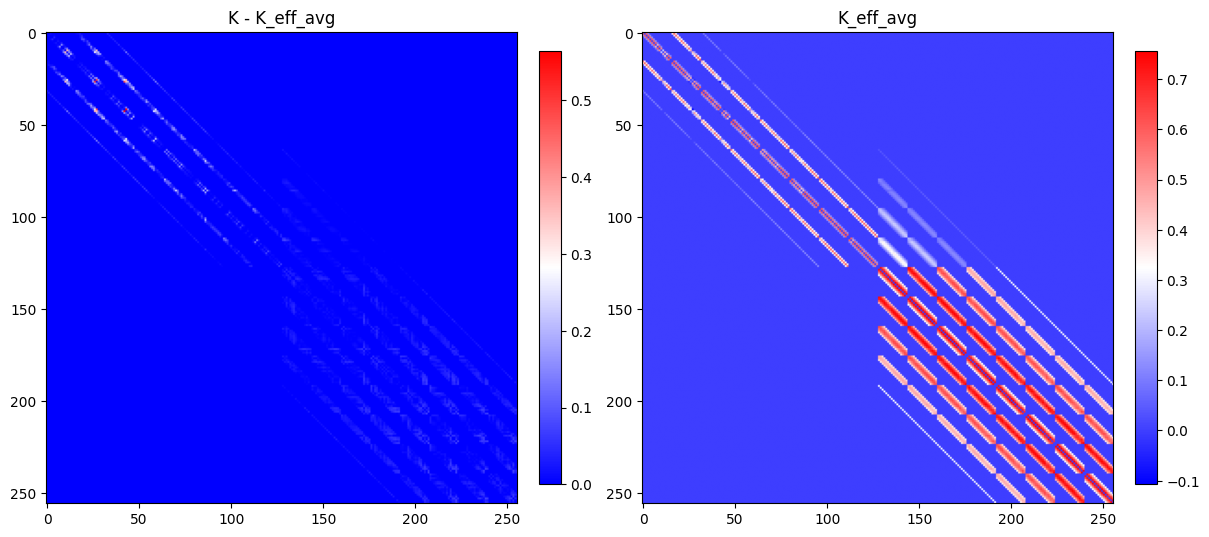

In [2]:
# K_eff_T = compute_effective_coupling(sim.results["theta"][-1], sim.coupling.K)
K_eff_avg = avg_effective_coupling(sim.results["theta"], sim.coupling.K)

K_diff = sim.coupling.K - K_eff_avg

fig,ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
im = ax[0].imshow(K_diff, cmap="bwr")
ax[0].set_title("K - K_eff_avg")
fig.colorbar(im,ax=ax[0],fraction=0.046, pad=0.04)

im = ax[1].imshow(K_eff_avg, cmap="bwr")
ax[1].set_title("K_eff_avg")
fig.colorbar(im,ax=ax[1],fraction=0.046, pad=0.04)


G_eff = create_cortical_graph(K_eff_avg, omega=sim.params.omega)

Text(0.5, 0.98, 'Base coupling network metrics')

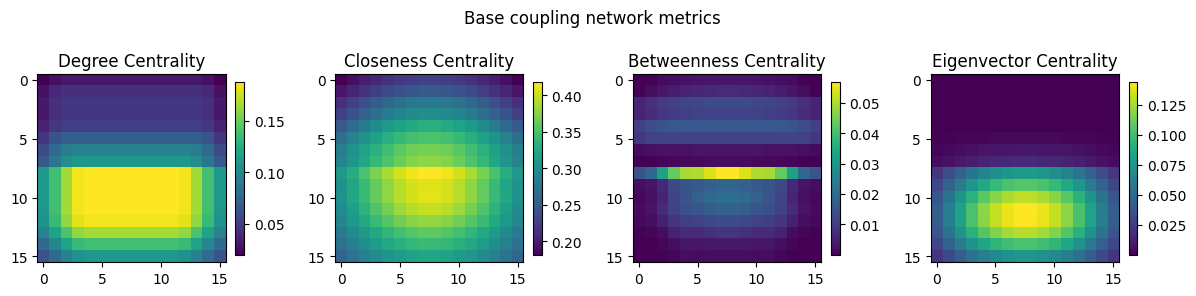

In [3]:
deg_cent = get_deg_centrality(G)
closeness = get_closeness_centrality(G)
betweenness = get_betweenness_centrality(G)
eigenvector = get_eigenvector_centrality(G)

fig,ax = plt.subplots(1,4,figsize=(12,3),constrained_layout=True)
im = ax[0].imshow(deg_cent.reshape(grid_shape))
ax[0].set_title("Degree Centrality")
fig.colorbar(im,ax=ax[0],fraction=0.046, pad=0.04)

im = ax[1].imshow(closeness.reshape(grid_shape))
ax[1].set_title("Closeness Centrality")
fig.colorbar(im,ax=ax[1],fraction=0.046, pad=0.04)

im = ax[2].imshow(betweenness.reshape(grid_shape))
ax[2].set_title("Betweenness Centrality")
fig.colorbar(im,ax=ax[2],fraction=0.046, pad=0.04)

im = ax[3].imshow(eigenvector.reshape(grid_shape))
ax[3].set_title("Eigenvector Centrality")
fig.colorbar(im,ax=ax[3],fraction=0.046, pad=0.04)

fig.suptitle("Base coupling network metrics")

Text(0.5, 0.98, 'Effective coupling network metrics')

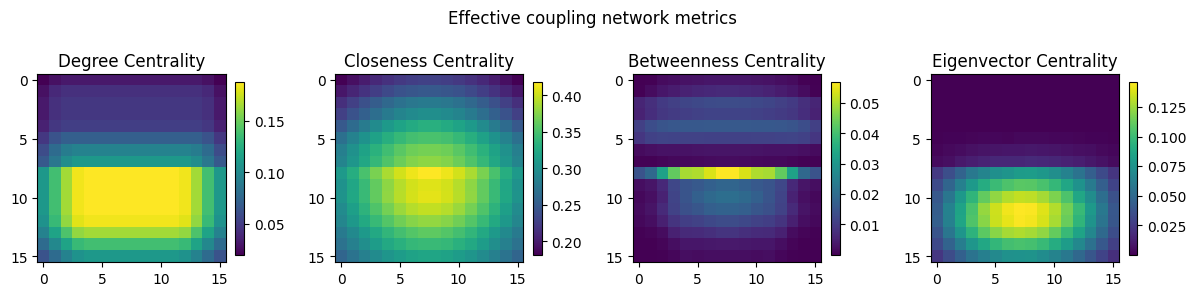

In [4]:
deg_cent = get_deg_centrality(G_eff)
closeness = get_closeness_centrality(G_eff)
betweenness = get_betweenness_centrality(G_eff)
eigenvector = get_eigenvector_centrality(G_eff)

fig,ax = plt.subplots(1,4,figsize=(12,3),constrained_layout=True)
im = ax[0].imshow(deg_cent.reshape(grid_shape))
ax[0].set_title("Degree Centrality")
fig.colorbar(im,ax=ax[0],fraction=0.046, pad=0.04)

im = ax[1].imshow(closeness.reshape(grid_shape))
ax[1].set_title("Closeness Centrality")
fig.colorbar(im,ax=ax[1],fraction=0.046, pad=0.04)

im = ax[2].imshow(betweenness.reshape(grid_shape))
ax[2].set_title("Betweenness Centrality")
fig.colorbar(im,ax=ax[2],fraction=0.046, pad=0.04)

im = ax[3].imshow(eigenvector.reshape(grid_shape))
ax[3].set_title("Eigenvector Centrality")
fig.colorbar(im,ax=ax[3],fraction=0.046, pad=0.04)

fig.suptitle("Effective coupling network metrics")

### 2) Adjoint metrics

  max |dR/dK| = 7.501076e-02
  max |dR/domega| = 9.190721e-02
  max |dR/dK| (averaged) = 7.338384e-02
  max |dR/domega| (averaged) = 7.676411e-02


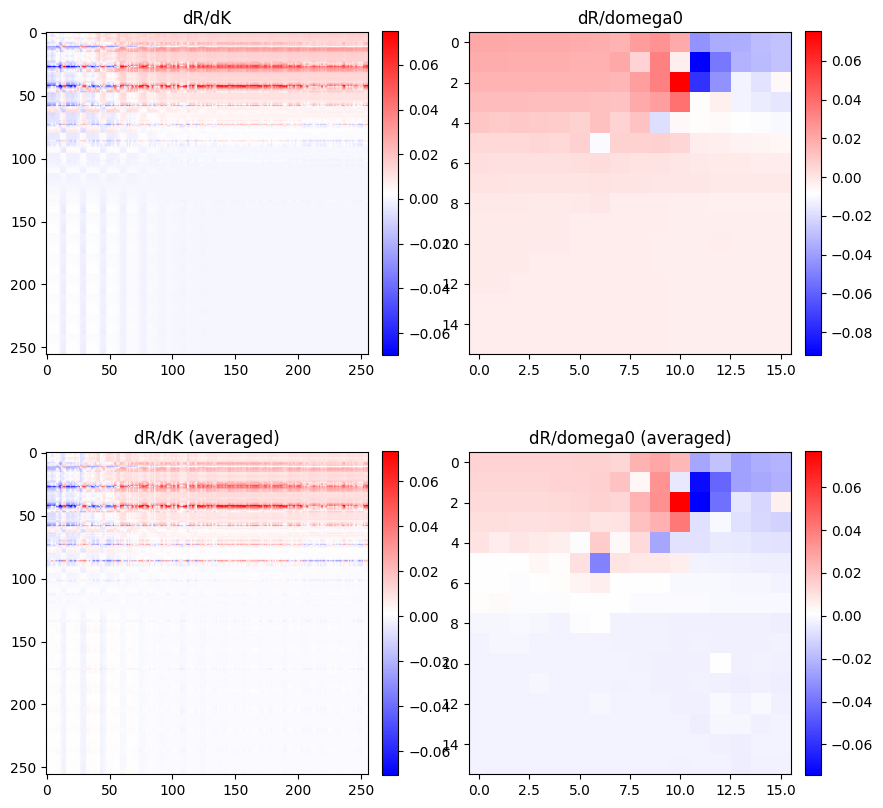

In [5]:
t0, t1 = 0.0, T_END
ts = jnp.arange(t0, t1 + dt / 2, dt)
ts = ts[ts <= t1]

g = grads_final_R(sim.params, sim.theta0, t0=0.0, t1=T_END, dt=dt, ts=[T_END])
g_avg = grads_mean_R(sim.params, sim.theta0, t0=0.0, t1=T_END, dt=dt, ts=ts)

dR_dK = np.asarray(g.K)
dR_domega = np.asarray(g.omega)

dR_dK_avg = np.asarray(g_avg.K)
dR_domega_avg = np.asarray(g_avg.omega)

dR_domega_2d = sim.grid.unflatten(dR_domega)
dR_domega_avg_2d = sim.grid.unflatten(dR_domega_avg)

# Statistics
print(f"  max |dR/dK| = {float(np.max(np.abs(dR_dK))):.6e}")
print(f"  max |dR/domega| = {float(np.max(np.abs(dR_domega))):.6e}")
print(f"  max |dR/dK| (averaged) = {float(np.max(np.abs(dR_dK_avg))):.6e}")
print(f"  max |dR/domega| (averaged) = {float(np.max(np.abs(dR_domega_avg))):.6e}")

# Plot coupling matrix
fig, axs = plt.subplots(2,2,figsize=(10,10))
axs = axs.ravel()

im = axs[0].imshow(dR_dK, cmap="bwr")
axs[0].set_title("dR/dK")
fig.colorbar(im,ax=axs[0],fraction=0.046, pad=0.04)

im = axs[1].imshow(dR_domega_2d, cmap="bwr")
axs[1].set_title("dR/domega0")
fig.colorbar(im,ax=axs[1],fraction=0.046, pad=0.04)  

im = axs[2].imshow(dR_dK_avg, cmap="bwr")
axs[2].set_title("dR/dK (averaged)")
fig.colorbar(im,ax=axs[2],fraction=0.046, pad=0.04)

im = axs[3].imshow(dR_domega_avg_2d, cmap="bwr")
axs[3].set_title("dR/domega0 (averaged)")
fig.colorbar(im,ax=axs[3],fraction=0.046, pad=0.04)

  max I_final: 1.151967e-01
  max I_mean: 1.159727e-01
  max |dRf/dalpha| = 1.151967e-01
  max |dRm/dalpha| = 1.159727e-01


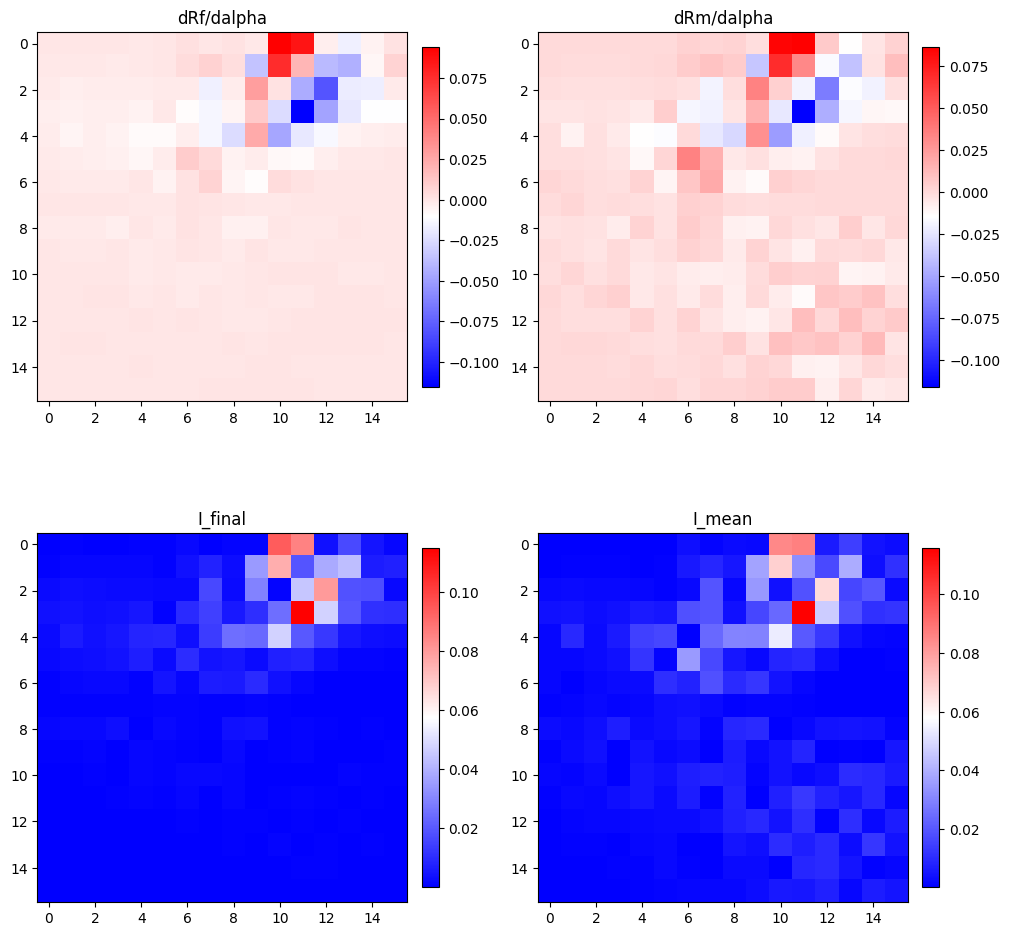

In [8]:
I_final = node_importance_from_gradK(sim.params.K, g.K)
I_mean = node_importance_from_gradK(sim.params.K, g_avg.K)

alpha0 = jnp.zeros((sim.grid.n_total,), dtype=sim.params.K.dtype)
dRf_dalpha = grads_final_R_alpha(sim.params, alpha0, sim.theta0, t0, t1, dt, ts=ts)
dRm_dalpha = grads_mean_R_alpha(sim.params, alpha0, sim.theta0, t0, t1, dt, ts=ts)

#Statistics
print(f"  max I_final: {float(np.max(I_final)):.6e}")
print(f"  max I_mean: {float(np.max(I_mean)):.6e}")
print(f"  max |dRf/dalpha| = {float(np.max(np.abs(dRf_dalpha))):.6e}")
print(f"  max |dRm/dalpha| = {float(np.max(np.abs(dRm_dalpha))):.6e}")

#Plot
fig,ax = plt.subplots(2,2,figsize=(10,10),constrained_layout=True)
ax = ax.ravel()

im = ax[0].imshow(dRf_dalpha.reshape(grid_shape), cmap="bwr")
ax[0].set_title("dRf/dalpha")
fig.colorbar(im,ax=ax[0],fraction=0.046, pad=0.04)

im = ax[1].imshow(dRm_dalpha.reshape(grid_shape), cmap="bwr")
ax[1].set_title("dRm/dalpha")
fig.colorbar(im,ax=ax[1],fraction=0.046, pad=0.04)

im = ax[2].imshow(I_final.reshape(grid_shape), cmap="bwr")
ax[2].set_title("I_final")
fig.colorbar(im,ax=ax[2],fraction=0.046, pad=0.04)

im = ax[3].imshow(I_mean.reshape(grid_shape), cmap="bwr")
ax[3].set_title("I_mean")
fig.colorbar(im,ax=ax[3],fraction=0.046, pad=0.04)